# CXR-LT 2023 Continued Data Checks

This notebook continues the TODO list from `cxr-lt-2023.ipynb`:

1. Study-level aggregation and frontal/lateral pairing.
2. Patient timeline behavior.
3. Label co-occurrence and correlations.
4. View-conditioned prevalence.
5. Image path availability.
6. Text linkage readiness against MIMIC-CXR report metadata.

Run it from `data/00-examine-data`, matching the first notebook.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)

cwd = Path.cwd()
if cwd.name != "00-examine-data":
    raise Exception("Please run this notebook from the 00-examine-data directory")

root_dir = cwd.parents[1]
data_dir = root_dir / "data"
cxr_lt_2023_dir = data_dir / "CXR-LT" / "cxr-lt-multi-label-long-tailed-classification-on-chest-x-rays-2.0.0" / "cxr-lt-2023"
mimic_cxr_dir = data_dir / "MIMIC-CXR"
mimic_cxr_jpg_dir = data_dir / "MIMIC-CXR-JPG"

print(f"root_dir: {root_dir}")
print(f"cxr_lt_2023_dir: {cxr_lt_2023_dir}")
print(f"mimic_cxr_dir exists: {mimic_cxr_dir.exists()}")
print(f"mimic_cxr_jpg_dir exists: {mimic_cxr_jpg_dir.exists()}")

root_dir: /Volumes/HP_P900/Users/tungnguyen/Programming/Chest-Medical-Image-Fusion-for-Multimodal-Clinical-Analysis
cxr_lt_2023_dir: /Volumes/HP_P900/Users/tungnguyen/Programming/Chest-Medical-Image-Fusion-for-Multimodal-Clinical-Analysis/data/CXR-LT/cxr-lt-multi-label-long-tailed-classification-on-chest-x-rays-2.0.0/cxr-lt-2023
mimic_cxr_dir exists: True
mimic_cxr_jpg_dir exists: True


## 0) Load CXR-LT Splits

This repeats the first notebook's loading conventions so the continuation can run by itself.

In [2]:
CSV_FILES = {
    "train": "train.csv",
    "development": "development.csv",
    "test": "test.csv",
}

ID_COLUMNS = [
    "dicom_id",
    "subject_id",
    "study_id",
    "ViewPosition",
    "ViewCodeSequence_CodeMeaning",
    "path",
]


def load_dataset(filename: str) -> pd.DataFrame:
    return pd.read_csv(cxr_lt_2023_dir / filename)


def load_first_existing(paths: list[Path]) -> tuple[pd.DataFrame | None, Path | None]:
    for path in paths:
        if path.exists():
            return pd.read_csv(path), path
    return None, None


analysis_splits = {name: load_dataset(filename) for name, filename in CSV_FILES.items()}
train_df = analysis_splits["train"]
label_cols = [column for column in train_df.columns if column not in ID_COLUMNS]

split_overview_df = pd.DataFrame(
    [
        {
            "split": split_name,
            "rows": len(df),
            "subjects": df["subject_id"].nunique(),
            "studies": df["study_id"].nunique(),
            "dicoms": df["dicom_id"].nunique(),
        }
        for split_name, df in analysis_splits.items()
    ]
)

display(split_overview_df)
print(f"Detected {len(label_cols)} label columns")
label_cols

,split,rows,subjects,studies,dicoms
0,train,264849,45766,160052,264849
1,development,36769,6538,22291,36769
2,test,75492,13075,45492,75492


Detected 26 label columns


['Atelectasis',
 'Calcification of the Aorta',
 'Cardiomegaly',
 'Consolidation',
 'Edema',
 'Emphysema',
 'Enlarged Cardiomediastinum',
 'Fibrosis',
 'Fracture',
 'Hernia',
 'Infiltration',
 'Lung Lesion',
 'Lung Opacity',
 'Mass',
 'No Finding',
 'Nodule',
 'Pleural Effusion',
 'Pleural Other',
 'Pleural Thickening',
 'Pneumomediastinum',
 'Pneumonia',
 'Pneumoperitoneum',
 'Pneumothorax',
 'Subcutaneous Emphysema',
 'Support Devices',
 'Tortuous Aorta']

## Shared Helpers

The helpers below keep the later checks short and make missing optional MIMIC files explicit.

In [3]:
FRONTAL_VIEWS = {"AP", "PA"}
LATERAL_VIEWS = {"LATERAL", "LL", "LPO", "RPO"}
MAJOR_VIEWS = ["AP", "PA", "LATERAL"]


def normalize_view_position(series: pd.Series) -> pd.Series:
    return series.fillna("Missing").astype(str).str.strip().str.upper().replace({"": "Missing"})


def format_view_combo(views: tuple[str, ...]) -> str:
    return " + ".join(views) if views else "Missing"


def has_any_view(views: tuple[str, ...], candidates: set[str]) -> bool:
    return bool(set(views) & candidates)


def parse_mimic_study_datetime(df: pd.DataFrame) -> pd.Series:
    if "StudyDate" not in df.columns or "StudyTime" not in df.columns:
        return pd.Series(pd.NaT, index=df.index)

    date_text = (
        df["StudyDate"]
        .astype("string")
        .str.replace(r"\.0$", "", regex=True)
        .str.zfill(8)
    )
    time_text = (
        df["StudyTime"]
        .astype("string")
        .str.replace(r"\.0$", "", regex=True)
        .str.split(".")
        .str[0]
        .str.zfill(6)
        .str[:6]
    )
    return pd.to_datetime(date_text + time_text, format="%Y%m%d%H%M%S", errors="coerce")


def build_study_view_table(df: pd.DataFrame, label_columns: list[str]) -> pd.DataFrame:
    temp = df.assign(_view=normalize_view_position(df["ViewPosition"]))
    group_keys = ["subject_id", "study_id"]

    counts = (
        temp.groupby(group_keys, as_index=False)
        .agg(
            image_count=("dicom_id", "size"),
            unique_dicoms=("dicom_id", "nunique"),
        )
    )
    views = (
        temp.groupby(group_keys)["_view"]
        .agg(lambda values: tuple(sorted(set(values))))
        .rename("views")
        .reset_index()
    )
    study_labels = (
        temp.groupby(group_keys)[label_columns]
        .max()
        .sum(axis=1)
        .rename("positive_labels_per_study")
        .reset_index()
    )

    study_table = counts.merge(views, on=group_keys).merge(study_labels, on=group_keys)
    study_table["view_combo"] = study_table["views"].map(format_view_combo)
    study_table["has_frontal"] = study_table["views"].map(lambda views: has_any_view(views, FRONTAL_VIEWS))
    study_table["has_lateral"] = study_table["views"].map(lambda views: has_any_view(views, LATERAL_VIEWS))
    study_table["has_pa"] = study_table["views"].map(lambda views: "PA" in views)
    study_table["has_ap"] = study_table["views"].map(lambda views: "AP" in views)
    study_table["has_frontal_and_lateral"] = study_table["has_frontal"] & study_table["has_lateral"]
    return study_table


def summarize_study_views(split_frames: dict[str, pd.DataFrame], label_columns: list[str]) -> tuple[pd.DataFrame, pd.DataFrame]:
    tables = []
    summary_rows = []

    for split_name, df in split_frames.items():
        study_table = build_study_view_table(df, label_columns).assign(split=split_name)
        tables.append(study_table)
        summary_rows.append(
            {
                "split": split_name,
                "studies": len(study_table),
                "single_image_studies_pct": (study_table["image_count"] == 1).mean() * 100,
                "median_images_per_study": study_table["image_count"].median(),
                "frontal_and_lateral_studies_pct": study_table["has_frontal_and_lateral"].mean() * 100,
                "pa_and_lateral_studies_pct": (study_table["has_pa"] & study_table["has_lateral"]).mean() * 100,
                "ap_and_lateral_studies_pct": (study_table["has_ap"] & study_table["has_lateral"]).mean() * 100,
                "median_positive_labels_per_study": study_table["positive_labels_per_study"].median(),
            }
        )

    all_studies = pd.concat(tables, ignore_index=True)
    summary = pd.DataFrame(summary_rows)
    return all_studies, summary


def plot_top_view_combos(study_table: pd.DataFrame, top_n: int = 12) -> None:
    combo_order = (
        study_table.query("split == 'train'")["view_combo"]
        .value_counts()
        .head(top_n)
        .index
    )
    plot_df = study_table[study_table["view_combo"].isin(combo_order)]

    plt.figure(figsize=(12, 5))
    sns.countplot(data=plot_df, y="view_combo", hue="split", order=combo_order)
    plt.title(f"Top {top_n} study view combinations")
    plt.xlabel("Study count")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

## 1) Study-Level Aggregation

This checks whether a `study_id` usually has a frontal view, a lateral view, or both. This matters for multi-view fusion because the image-level rows are not the same unit as a clinical exam.

,split,studies,single_image_studies_pct,median_images_per_study,frontal_and_lateral_studies_pct,pa_and_lateral_studies_pct,ap_and_lateral_studies_pct,median_positive_labels_per_study
0,train,160052,45.048484,2.0,46.178742,37.455952,8.810262,2.0
1,development,22291,45.471266,2.0,46.045489,37.073258,9.052981,2.0
2,test,45492,44.926580,2.0,46.302647,37.472523,8.885079,2.0


,subject_id,study_id,image_count,view_combo,has_frontal_and_lateral,positive_labels_per_study
0,10000032,50414267,2,LATERAL + PA,True,3
1,10000032,53189527,2,LATERAL + PA,True,1
2,10000032,53911762,2,AP,False,1
3,10000032,56699142,1,AP,False,1
4,10000764,57375967,3,AP + LATERAL,True,3
5,10000898,50771383,2,LATERAL + PA,True,1
6,10000898,54205396,3,LATERAL + PA,True,1
7,10000980,50985099,2,LL + PA,True,2
8,10000980,51967283,1,AP,False,4
9,10000980,54577367,2,AP + LATERAL,True,2


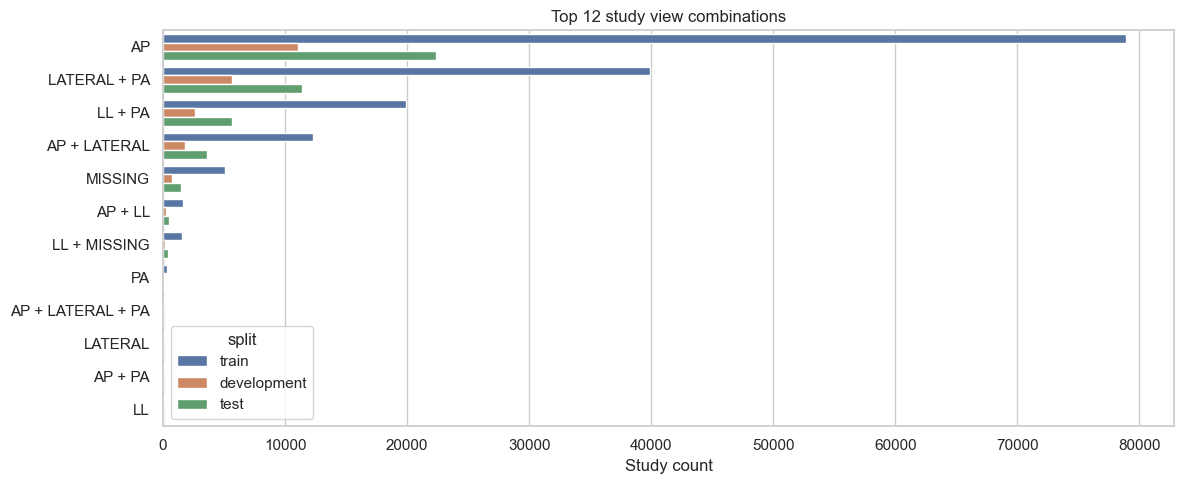

In [4]:
study_table_df, study_view_summary_df = summarize_study_views(analysis_splits, label_cols)

display(study_view_summary_df)
display(
    study_table_df
    .query("split == 'train'")
    [
        [
            "subject_id",
            "study_id",
            "image_count",
            "view_combo",
            "has_frontal_and_lateral",
            "positive_labels_per_study",
        ]
    ]
    .head(10)
)

plot_top_view_combos(study_table_df, top_n=12)

## 2) Patient Timeline Behavior

The CXR-LT CSVs do not include acquisition time, so this joins MIMIC-CXR-JPG metadata when available. MIMIC dates are shifted, but within-patient ordering and intervals are still useful for repeat-exam analysis.

In [5]:
metadata_df, metadata_path = load_first_existing(
    [
        mimic_cxr_jpg_dir / "mimic-cxr-2.0.0-metadata.csv.gz",
        mimic_cxr_jpg_dir / "mimic-cxr-2.0.0-metadata.csv",
    ]
)

if metadata_df is None:
    print("MIMIC-CXR-JPG metadata was not found. Timeline cells will fall back to study_id ordering.")
    metadata_columns = ["dicom_id", "study_datetime"]
    metadata_for_join = pd.DataFrame(columns=metadata_columns)
else:
    print(f"Loaded metadata: {metadata_path}")
    metadata_df["study_datetime"] = parse_mimic_study_datetime(metadata_df)
    metadata_columns = [
        column
        for column in [
            "dicom_id",
            "StudyDate",
            "StudyTime",
            "study_datetime",
            "PerformedProcedureStepDescription",
            "ProcedureCodeSequence_CodeMeaning",
            "Rows",
            "Columns",
        ]
        if column in metadata_df.columns
    ]
    metadata_for_join = metadata_df[metadata_columns].copy()

all_labeled_images_df = pd.concat(
    [df.assign(split=split_name) for split_name, df in analysis_splits.items()],
    ignore_index=True,
).merge(metadata_for_join, on="dicom_id", how="left")

print(f"Rows with parsed study_datetime: {all_labeled_images_df['study_datetime'].notna().sum():,} / {len(all_labeled_images_df):,}")
display(all_labeled_images_df.head(3))

Loaded metadata: /Volumes/HP_P900/Users/tungnguyen/Programming/Chest-Medical-Image-Fusion-for-Multimodal-Clinical-Analysis/data/MIMIC-CXR-JPG/mimic-cxr-2.0.0-metadata.csv.gz
Rows with parsed study_datetime: 377,110 / 377,110


,dicom_id,subject_id,study_id,ViewPosition,ViewCodeSequence_CodeMeaning,path,Atelectasis,Calcification of the Aorta,Cardiomegaly,Consolidation,Edema,Emphysema,Enlarged Cardiomediastinum,Fibrosis,Fracture,Hernia,Infiltration,Lung Lesion,Lung Opacity,Mass,No Finding,Nodule,Pleural Effusion,Pleural Other,Pleural Thickening,Pneumomediastinum,Pneumonia,Pneumoperitoneum,Pneumothorax,Subcutaneous Emphysema,Support Devices,Tortuous Aorta,split,StudyDate,StudyTime,study_datetime,PerformedProcedureStepDescription,ProcedureCodeSequence_CodeMeaning,Rows,Columns
0,02aa804e-bde0afdd-112c0b34-7bc16630-4e384014,10000032,50414267,PA,postero-anterior,files/p10/p10000032/s50414267/02aa804e-bde0afd...,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,train,21800506,213014.531,2180-05-06 21:30:14,CHEST (PA AND LAT),CHEST (PA AND LAT),3056,2544
1,174413ec-4ec4c1f7-34ea26b7-c5f994f8-79ef1962,10000032,50414267,LATERAL,lateral,files/p10/p10000032/s50414267/174413ec-4ec4c1f...,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,train,21800506,213014.531,2180-05-06 21:30:14,CHEST (PA AND LAT),CHEST (PA AND LAT),3056,2544
2,2a2277a9-b0ded155-c0de8eb9-c124d10e-82c5caab,10000032,53189527,PA,postero-anterior,files/p10/p10000032/s53189527/2a2277a9-b0ded15...,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,train,21800626,165500.312,2180-06-26 16:55:00,CHEST (PA AND LAT),CHEST (PA AND LAT),3056,2544


In [6]:
def build_study_timeline(images_df: pd.DataFrame, label_columns: list[str]) -> pd.DataFrame:
    temp = images_df.assign(_view=normalize_view_position(images_df["ViewPosition"]))
    group_keys = ["split", "subject_id", "study_id"]

    base = (
        temp.groupby(group_keys, as_index=False)
        .agg(
            image_count=("dicom_id", "size"),
            study_datetime=("study_datetime", "min"),
            first_dicom_id=("dicom_id", "first"),
        )
    )
    views = (
        temp.groupby(group_keys)["_view"]
        .agg(lambda values: tuple(sorted(set(values))))
        .rename("views")
        .reset_index()
    )
    labels = (
        temp.groupby(group_keys)[label_columns]
        .max()
        .sum(axis=1)
        .rename("positive_labels_per_study")
        .reset_index()
    )

    timeline = base.merge(views, on=group_keys).merge(labels, on=group_keys)
    timeline["view_combo"] = timeline["views"].map(format_view_combo)
    timeline = timeline.sort_values(["split", "subject_id", "study_datetime", "study_id"], na_position="last")
    timeline["days_since_previous_study"] = (
        timeline.groupby(["split", "subject_id"])["study_datetime"]
        .diff()
        .dt.total_seconds()
        .div(86400)
    )
    return timeline


study_timeline_df = build_study_timeline(all_labeled_images_df, label_cols)

patient_timeline_summary_df = (
    study_timeline_df.groupby(["split", "subject_id"], as_index=False)
    .agg(
        study_count=("study_id", "nunique"),
        first_study_datetime=("study_datetime", "min"),
        last_study_datetime=("study_datetime", "max"),
        total_images=("image_count", "sum"),
    )
)
patient_timeline_summary_df["span_days"] = (
    patient_timeline_summary_df["last_study_datetime"] - patient_timeline_summary_df["first_study_datetime"]
).dt.total_seconds().div(86400)

split_patient_summary_df = (
    patient_timeline_summary_df.groupby("split")
    .agg(
        patients=("subject_id", "nunique"),
        patients_with_multiple_studies=("study_count", lambda values: int((values > 1).sum())),
        median_studies_per_patient=("study_count", "median"),
        max_studies_per_patient=("study_count", "max"),
        median_span_days=("span_days", "median"),
        max_span_days=("span_days", "max"),
    )
    .reset_index()
)
split_patient_summary_df["multiple_study_patient_pct"] = (
    split_patient_summary_df["patients_with_multiple_studies"] / split_patient_summary_df["patients"] * 100
)

display(split_patient_summary_df)
display(
    patient_timeline_summary_df
    .sort_values(["study_count", "span_days"], ascending=[False, False])
    .head(10)
)

,split,patients,patients_with_multiple_studies,median_studies_per_patient,max_studies_per_patient,median_span_days,max_span_days,multiple_study_patient_pct
0,development,6538,3242,1.0,80,0.0000,1842.605671,49.587030
1,test,13075,6468,1.0,131,0.0000,1845.636748,49.468451
2,train,45766,22974,2.0,158,0.0911,1846.212303,50.198838


,split,subject_id,study_count,first_study_datetime,last_study_datetime,total_images,span_days
49130,train,16454913,158,2144-06-30 14:40:38,2146-06-26 04:44:30,174,725.586019
14176,test,15936063,131,2161-02-05 15:09:55,2164-08-22 10:04:33,142,1293.787940
17305,test,18295542,127,2157-11-07 22:44:17,2161-12-31 14:02:37,131,1514.637731
28909,train,12043836,124,2135-10-29 18:22:24,2139-09-29 12:59:46,167,1430.775949
63896,train,19674244,108,2193-10-28 16:01:58,2197-01-02 05:18:06,130,1161.552870
45724,train,15689523,104,2158-03-20 12:39:57,2159-09-15 16:33:08,119,544.161933
52884,train,17277688,96,2184-02-12 14:36:11,2186-11-13 17:49:48,113,1005.134456
50072,train,16662316,95,2174-12-08 01:06:57,2178-05-16 02:27:54,169,1255.056215
27365,train,11717909,95,2129-09-12 20:50:52,2132-02-21 10:40:56,114,891.576435
22769,train,10699336,89,2158-01-08 05:52:15,2158-04-16 12:21:40,98,98.270428


In [7]:
top_patient_row = (
    patient_timeline_summary_df
    .sort_values(["study_count", "span_days"], ascending=[False, False])
    .head(1)
)

if top_patient_row.empty:
    print("No patient timeline rows available.")
else:
    top_split = top_patient_row.iloc[0]["split"]
    top_subject_id = top_patient_row.iloc[0]["subject_id"]
    print(f"Example repeat-exam patient: split={top_split}, subject_id={top_subject_id}")
    display(
        study_timeline_df
        .query("split == @top_split and subject_id == @top_subject_id")
        [
            [
                "split",
                "subject_id",
                "study_id",
                "study_datetime",
                "days_since_previous_study",
                "image_count",
                "view_combo",
                "positive_labels_per_study",
            ]
        ]
    )

Example repeat-exam patient: split=train, subject_id=16454913


,split,subject_id,study_id,study_datetime,days_since_previous_study,image_count,view_combo,positive_labels_per_study
171313,train,16454913,55797204,2144-06-30 14:40:38,NaN,2,LATERAL + PA,1
171376,train,16454913,59642620,2144-07-08 15:43:30,8.043657,1,AP,1
171331,train,16454913,56858300,2144-08-03 12:17:17,25.856794,2,AP + LATERAL,2
171348,train,16454913,58035269,2144-10-06 15:37:37,64.139120,1,AP,3
171230,train,16454913,50348196,2144-10-07 02:05:50,0.436262,1,AP,0
...,...,...,...,...,...,...,...,...
171282,train,16454913,53712624,2146-06-15 00:33:37,3.570139,1,AP,5
171285,train,16454913,53804071,2146-06-21 16:24:19,6.660208,1,AP,5
171239,train,16454913,50537382,2146-06-23 05:40:00,1.552558,1,AP,5
171294,train,16454913,54295931,2146-06-25 10:04:34,2.183727,2,AP,1


## 3) Label Co-occurrence And Correlations

Use the training split for these checks so downstream choices are driven by train data only. The correlation heatmap uses Pearson correlation on binary labels, which is the phi coefficient for two binary variables.

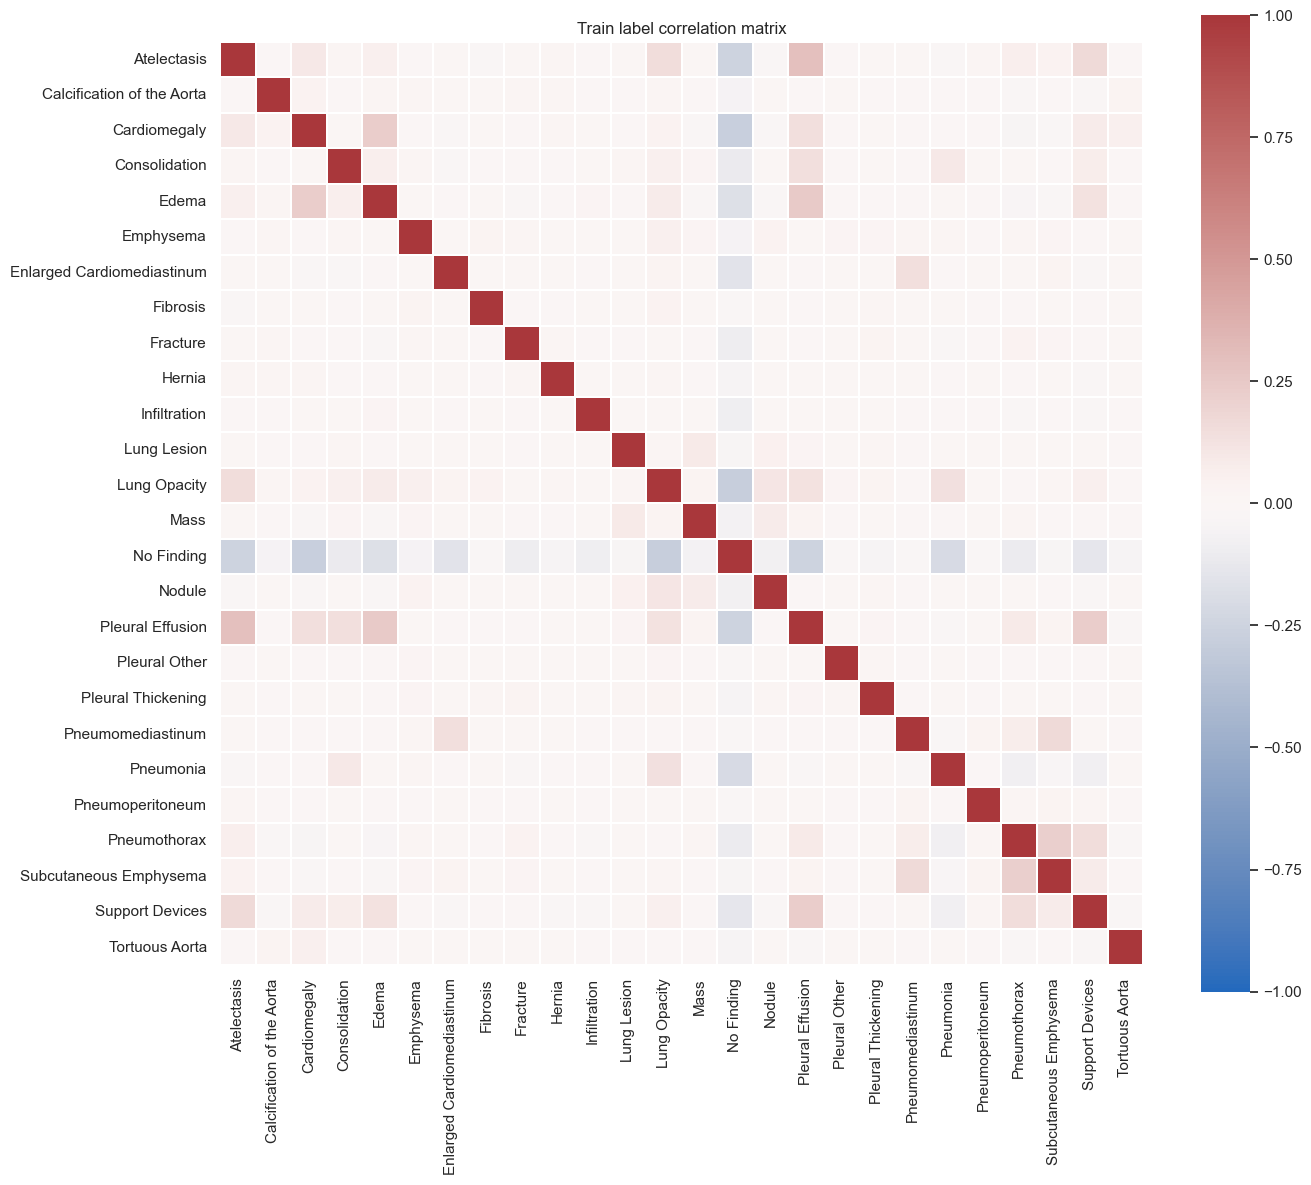

Most positively correlated label pairs


,left_label,right_label,correlation,cooccurrence_count,left_positive_count,right_positive_count
15,Atelectasis,Pleural Effusion,0.291329,32454,67597,69240
105,Edema,Pleural Effusion,0.247671,20252,38574,69240
287,Pleural Effusion,Support Devices,0.230101,35958,69240,89140
50,Cardiomegaly,Edema,0.229740,20943,76900,38574
319,Pneumothorax,Subcutaneous Emphysema,0.219621,1426,14983,2453
23,Atelectasis,Support Devices,0.169230,31985,67597,89140
307,Pneumomediastinum,Subcutaneous Emphysema,0.164787,235,788,2453
320,Pneumothorax,Support Devices,0.153261,9474,14983,89140
11,Atelectasis,Lung Opacity,0.150763,28392,67597,79931
62,Cardiomegaly,Pleural Effusion,0.148141,27930,76900,69240


Most negatively correlated label pairs


,left_label,right_label,correlation,cooccurrence_count,left_positive_count,right_positive_count
235,Lung Opacity,No Finding,-0.284893,0,79931,41869
60,Cardiomegaly,No Finding,-0.277177,0,76900,41869
260,No Finding,Pleural Effusion,-0.257809,0,41869,69240
13,Atelectasis,No Finding,-0.253668,0,67597,41869
264,No Finding,Pneumonia,-0.204112,0,41869,48093
103,Edema,No Finding,-0.178913,0,38574,41869
142,Enlarged Cardiomediastinum,No Finding,-0.155221,0,30119,41869
268,No Finding,Support Devices,-0.138943,7748,41869,89140
82,Consolidation,No Finding,-0.110015,0,16038,41869
266,No Finding,Pneumothorax,-0.106111,0,41869,14983


In [8]:
def label_pair_correlation_table(df: pd.DataFrame, label_columns: list[str]) -> pd.DataFrame:
    corr = df[label_columns].corr()
    pairs = []
    for left_idx, left_label in enumerate(label_columns):
        for right_label in label_columns[left_idx + 1 :]:
            pairs.append(
                {
                    "left_label": left_label,
                    "right_label": right_label,
                    "correlation": corr.loc[left_label, right_label],
                    "cooccurrence_count": int(((df[left_label] == 1) & (df[right_label] == 1)).sum()),
                    "left_positive_count": int(df[left_label].sum()),
                    "right_positive_count": int(df[right_label].sum()),
                }
            )
    return pd.DataFrame(pairs).dropna(subset=["correlation"])


train_corr_df = train_df[label_cols].corr()
pair_corr_df = label_pair_correlation_table(train_df, label_cols)

plt.figure(figsize=(14, 12))
sns.heatmap(train_corr_df, cmap="vlag", center=0, vmin=-1, vmax=1, square=True, linewidths=0.2)
plt.title("Train label correlation matrix")
plt.tight_layout()
plt.show()

print("Most positively correlated label pairs")
display(pair_corr_df.sort_values("correlation", ascending=False).head(15))

print("Most negatively correlated label pairs")
display(pair_corr_df.sort_values("correlation", ascending=True).head(15))

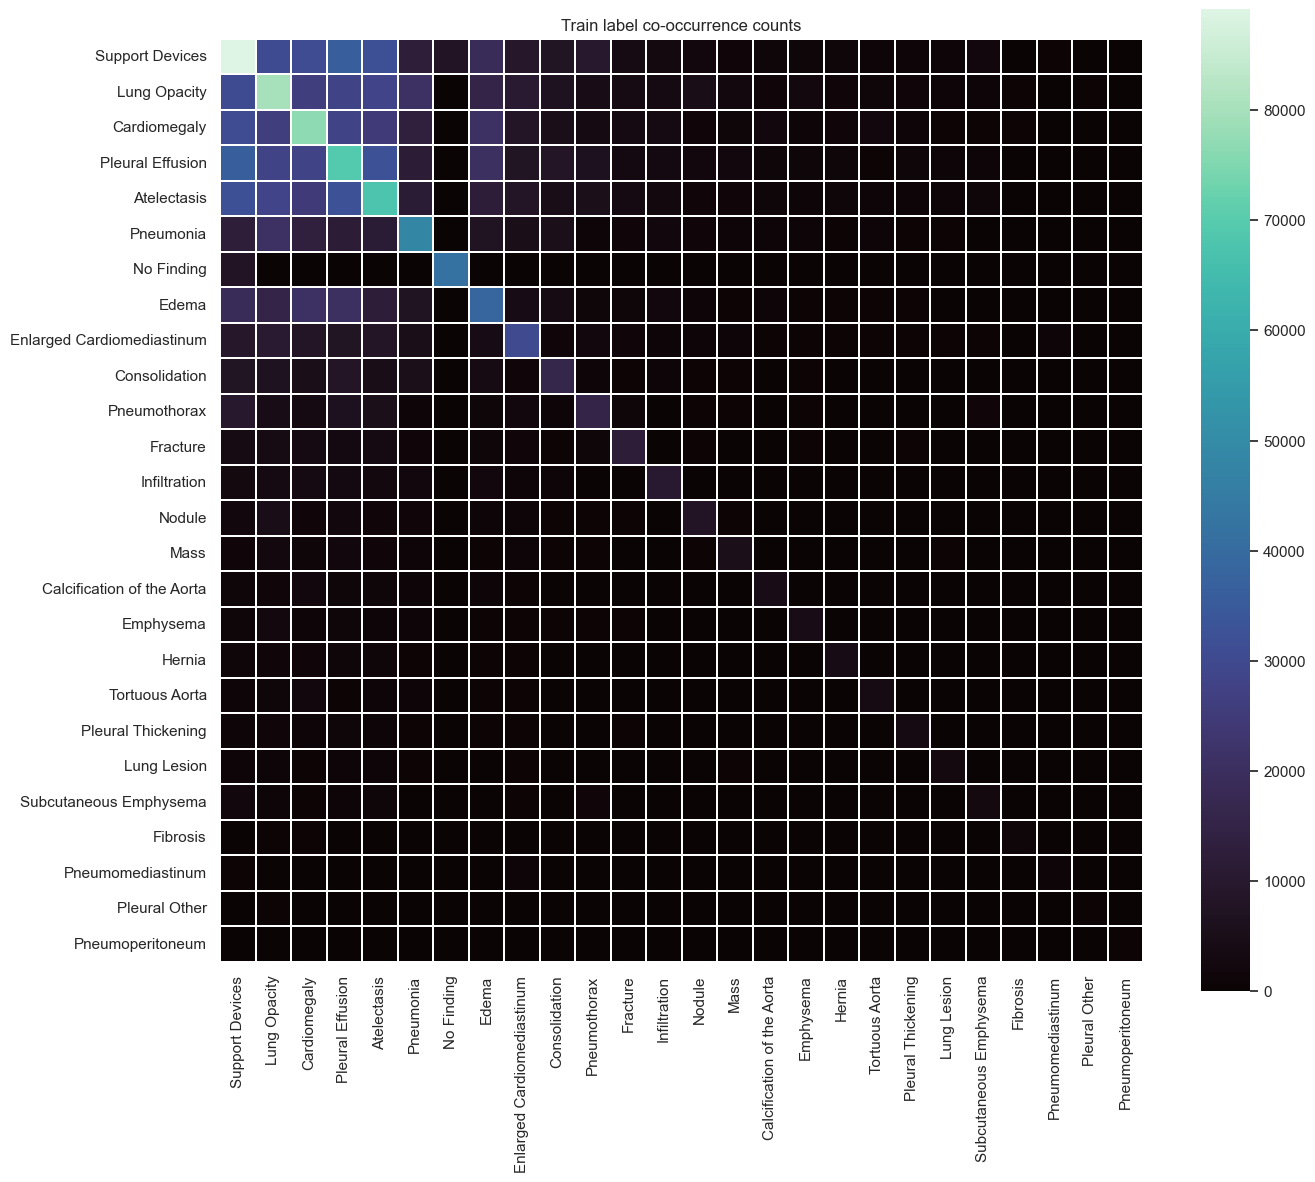

,Support Devices,Lung Opacity,Cardiomegaly,Pleural Effusion,Atelectasis,Pneumonia,No Finding,Edema,Enlarged Cardiomediastinum,Consolidation
Support Devices,89140,30398,30733,35958,31985,12262,7748,18792,9328,7603
Lung Opacity,30398,79931,25789,27857,28392,20952,0,15120,10542,6625
Cardiomegaly,30733,25789,76900,27930,24723,13553,0,20943,8089,4989
Pleural Effusion,35958,27857,27930,69240,32454,11595,0,20252,7629,8098
Atelectasis,31985,28392,24723,32454,67597,11147,0,12185,8211,4546
Pneumonia,12262,20952,13553,11595,11147,48093,0,7145,5134,5325
No Finding,7748,0,0,0,0,0,41869,0,0,0
Edema,18792,15120,20943,20252,12185,7145,0,38574,3940,3828
Enlarged Cardiomediastinum,9328,10542,8089,7629,8211,5134,0,3940,30119,1508
Consolidation,7603,6625,4989,8098,4546,5325,0,3828,1508,16038


In [9]:
train_cooccurrence_df = train_df[label_cols].T.dot(train_df[label_cols])
label_order = train_df[label_cols].sum().sort_values(ascending=False).index

plt.figure(figsize=(14, 12))
sns.heatmap(
    train_cooccurrence_df.loc[label_order, label_order],
    cmap="mako",
    square=True,
    linewidths=0.2,
)
plt.title("Train label co-occurrence counts")
plt.tight_layout()
plt.show()

display(train_cooccurrence_df.loc[label_order, label_order].iloc[:10, :10])

## 4) View-Conditioned Prevalence

This compares label rates for `AP`, `PA`, and `LATERAL`. It is useful for checking whether a label is view-dependent enough that frontal and lateral encoders should be treated separately.

,split,ViewPosition,row_count
78,development,AP,14478
104,development,LATERAL,8239
130,development,PA,9305
156,test,AP,29383
182,test,LATERAL,16596
208,test,PA,19297
0,train,AP,103312
26,train,LATERAL,58018
52,train,PA,67559


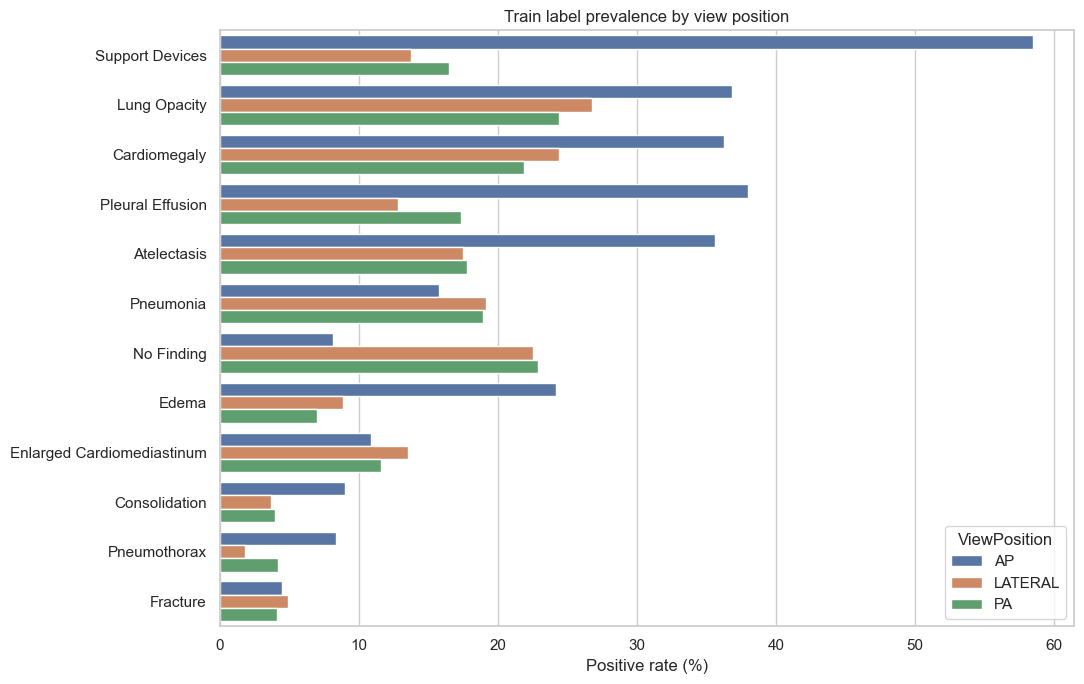

ViewPosition,AP,LATERAL,PA
label,,,
Support Devices,58.504,13.760,16.498
Lung Opacity,36.861,26.754,24.407
Cardiomegaly,36.243,24.363,21.896
Pleural Effusion,37.981,12.770,17.323
Atelectasis,35.570,17.484,17.776
Pneumonia,15.716,19.154,18.880
No Finding,8.157,22.481,22.850
Edema,24.162,8.813,6.964
Enlarged Cardiomediastinum,10.854,13.494,11.553


In [10]:
def view_conditioned_prevalence(
    split_frames: dict[str, pd.DataFrame],
    label_columns: list[str],
    major_views: list[str] = MAJOR_VIEWS,
) -> pd.DataFrame:
    rows = []
    for split_name, df in split_frames.items():
        temp = df.assign(_view=normalize_view_position(df["ViewPosition"]))
        for view_name, view_df in temp[temp["_view"].isin(major_views)].groupby("_view"):
            for label in label_columns:
                positives = int(view_df[label].sum())
                rows.append(
                    {
                        "split": split_name,
                        "ViewPosition": view_name,
                        "label": label,
                        "row_count": len(view_df),
                        "positive_count": positives,
                        "positive_rate_pct": positives / len(view_df) * 100 if len(view_df) else np.nan,
                    }
                )
    return pd.DataFrame(rows)


view_prevalence_df = view_conditioned_prevalence(analysis_splits, label_cols)
view_counts_df = (
    view_prevalence_df[["split", "ViewPosition", "row_count"]]
    .drop_duplicates()
    .sort_values(["split", "ViewPosition"])
)

display(view_counts_df)

top_train_labels = train_df[label_cols].sum().sort_values(ascending=False).head(12).index.tolist()
plot_df = view_prevalence_df.query("split == 'train' and label in @top_train_labels")

plt.figure(figsize=(11, 7))
sns.barplot(data=plot_df, x="positive_rate_pct", y="label", hue="ViewPosition", order=top_train_labels)
plt.title("Train label prevalence by view position")
plt.xlabel("Positive rate (%)")
plt.ylabel("")
plt.tight_layout()
plt.show()

display(
    plot_df.pivot(index="label", columns="ViewPosition", values="positive_rate_pct")
    .loc[top_train_labels]
    .round(3)
)

## 5) Image Availability And Path Sanity

CXR-LT `path` values are relative to the MIMIC-CXR-JPG root. This checks whether the expected JPG files are present locally before dataloader work.

In [11]:
def resolve_relative_path(root: Path, path_value: str) -> Path:
    path = Path(path_value)
    return path if path.is_absolute() else root / path


def summarize_image_paths(split_frames: dict[str, pd.DataFrame], image_root: Path) -> pd.DataFrame:
    rows = []
    for split_name, df in split_frames.items():
        paths = df["path"].dropna().astype(str)
        exists_flags = paths.map(lambda value: resolve_relative_path(image_root, value).is_file())
        rows.append(
            {
                "split": split_name,
                "rows": len(df),
                "path_values": len(paths),
                "unique_paths": paths.nunique(),
                "duplicate_path_rows": int(paths.duplicated().sum()),
                "jpg_extension_rows": int(paths.str.lower().str.endswith(".jpg").sum()),
                "existing_files": int(exists_flags.sum()),
                "missing_files": int((~exists_flags).sum()),
                "existing_file_pct": exists_flags.mean() * 100 if len(exists_flags) else np.nan,
            }
        )
    return pd.DataFrame(rows)


image_root = mimic_cxr_jpg_dir
print(f"image_root: {image_root}")
print(f"image_root exists: {image_root.exists()}")
print(f"image files directory exists: {(image_root / 'files').exists()}")

image_path_summary_df = summarize_image_paths(analysis_splits, image_root)
display(image_path_summary_df)

missing_train_paths = train_df.loc[
    ~train_df["path"].astype(str).map(lambda value: resolve_relative_path(image_root, value).is_file()),
    ["dicom_id", "subject_id", "study_id", "ViewPosition", "path"],
].head(10)

print("Sample missing train image paths")
display(missing_train_paths)

image_root: /Volumes/HP_P900/Users/tungnguyen/Programming/Chest-Medical-Image-Fusion-for-Multimodal-Clinical-Analysis/data/MIMIC-CXR-JPG
image_root exists: True
image files directory exists: False


,split,rows,path_values,unique_paths,duplicate_path_rows,jpg_extension_rows,existing_files,missing_files,existing_file_pct
0,train,264849,264849,264849,0,264849,0,264849,0.0
1,development,36769,36769,36769,0,36769,0,36769,0.0
2,test,75492,75492,75492,0,75492,0,75492,0.0


Sample missing train image paths


,dicom_id,subject_id,study_id,ViewPosition,path
0,02aa804e-bde0afdd-112c0b34-7bc16630-4e384014,10000032,50414267,PA,files/p10/p10000032/s50414267/02aa804e-bde0afd...
1,174413ec-4ec4c1f7-34ea26b7-c5f994f8-79ef1962,10000032,50414267,LATERAL,files/p10/p10000032/s50414267/174413ec-4ec4c1f...
2,2a2277a9-b0ded155-c0de8eb9-c124d10e-82c5caab,10000032,53189527,PA,files/p10/p10000032/s53189527/2a2277a9-b0ded15...
3,e084de3b-be89b11e-20fe3f9f-9c8d8dfe-4cfd202c,10000032,53189527,LATERAL,files/p10/p10000032/s53189527/e084de3b-be89b11...
4,68b5c4b1-227d0485-9cc38c3f-7b84ab51-4b472714,10000032,53911762,AP,files/p10/p10000032/s53911762/68b5c4b1-227d048...
5,fffabebf-74fd3a1f-673b6b41-96ec0ac9-2ab69818,10000032,53911762,AP,files/p10/p10000032/s53911762/fffabebf-74fd3a1...
6,ea030e7a-2e3b1346-bc518786-7a8fd698-f673b44c,10000032,56699142,AP,files/p10/p10000032/s56699142/ea030e7a-2e3b134...
7,096052b7-d256dc40-453a102b-fa7d01c6-1b22c6b4,10000764,57375967,AP,files/p10/p10000764/s57375967/096052b7-d256dc4...
8,b79e55c3-735ce5ac-64412506-cdc9ea79-f1af521f,10000764,57375967,LATERAL,files/p10/p10000764/s57375967/b79e55c3-735ce5a...
9,dcfeeac4-1597e318-d0e6736a-8b2c2238-47ac3f1b,10000764,57375967,LATERAL,files/p10/p10000764/s57375967/dcfeeac4-1597e31...


## 6) Text Linkage Readiness

This joins CXR-LT studies to the MIMIC-CXR study list. A successful index join means the label row can be paired to a report path. File existence is a separate check because this workstation may have metadata without the report text tree.

In [12]:
study_list_df, study_list_path = load_first_existing(
    [
        mimic_cxr_dir / "cxr-study-list.csv.gz",
        mimic_cxr_dir / "cxr-study-list.csv",
    ]
)

if study_list_df is None:
    print("MIMIC-CXR study list was not found. Report linkage cannot be checked.")
    report_link_summary_df = pd.DataFrame()
    linked_reports_df = pd.DataFrame()
else:
    print(f"Loaded study list: {study_list_path}")
    study_list_for_join = study_list_df.rename(columns={"path": "report_path"})
    unique_studies_df = pd.concat(
        [
            df[["subject_id", "study_id"]].drop_duplicates().assign(split=split_name)
            for split_name, df in analysis_splits.items()
        ],
        ignore_index=True,
    )
    linked_reports_df = unique_studies_df.merge(
        study_list_for_join[["subject_id", "study_id", "report_path"]],
        on=["subject_id", "study_id"],
        how="left",
    )
    linked_reports_df["has_report_index"] = linked_reports_df["report_path"].notna()
    linked_reports_df["report_file_exists"] = linked_reports_df["report_path"].fillna("").map(
        lambda value: (mimic_cxr_dir / value).is_file() if value else False
    )

    report_link_summary_df = (
        linked_reports_df.groupby("split")
        .agg(
            studies=("study_id", "nunique"),
            studies_with_report_index=("has_report_index", "sum"),
            studies_with_report_file=("report_file_exists", "sum"),
        )
        .reset_index()
    )
    report_link_summary_df["report_index_pct"] = (
        report_link_summary_df["studies_with_report_index"] / report_link_summary_df["studies"] * 100
    )
    report_link_summary_df["report_file_pct"] = (
        report_link_summary_df["studies_with_report_file"] / report_link_summary_df["studies"] * 100
    )

    print(f"report files directory exists: {(mimic_cxr_dir / 'files').exists()}")
    display(report_link_summary_df)
    display(linked_reports_df.head(10))

Loaded study list: /Volumes/HP_P900/Users/tungnguyen/Programming/Chest-Medical-Image-Fusion-for-Multimodal-Clinical-Analysis/data/MIMIC-CXR/cxr-study-list.csv.gz
report files directory exists: False


,split,studies,studies_with_report_index,studies_with_report_file,report_index_pct,report_file_pct
0,development,22291,22291,0,100.0,0.0
1,test,45492,45492,0,100.0,0.0
2,train,160052,160052,0,100.0,0.0


,subject_id,study_id,split,report_path,has_report_index,report_file_exists
0,10000032,50414267,train,files/p10/p10000032/s50414267.txt,True,False
1,10000032,53189527,train,files/p10/p10000032/s53189527.txt,True,False
2,10000032,53911762,train,files/p10/p10000032/s53911762.txt,True,False
3,10000032,56699142,train,files/p10/p10000032/s56699142.txt,True,False
4,10000764,57375967,train,files/p10/p10000764/s57375967.txt,True,False
5,10000898,50771383,train,files/p10/p10000898/s50771383.txt,True,False
6,10000898,54205396,train,files/p10/p10000898/s54205396.txt,True,False
7,10000980,50985099,train,files/p10/p10000980/s50985099.txt,True,False
8,10000980,51967283,train,files/p10/p10000980/s51967283.txt,True,False
9,10000980,54577367,train,files/p10/p10000980/s54577367.txt,True,False


In [13]:
def read_report_text(report_path: str, max_chars: int = 3000) -> str | None:
    if not report_path:
        return None
    full_path = mimic_cxr_dir / report_path
    if not full_path.is_file():
        return None
    return full_path.read_text(errors="replace")[:max_chars]


if linked_reports_df.empty or not linked_reports_df["report_file_exists"].any():
    print("No local report text files were found to preview.")
else:
    sample_report_row = linked_reports_df.query("report_file_exists").iloc[0]
    print(
        "Sample report: "
        f"split={sample_report_row['split']}, "
        f"subject_id={sample_report_row['subject_id']}, "
        f"study_id={sample_report_row['study_id']}"
    )
    print(read_report_text(sample_report_row["report_path"]))

No local report text files were found to preview.


## Notes For The Next Modeling Pass

Use these outputs to decide whether the modular dataloader should preserve study-level grouping, whether paired frontal/lateral samples are common enough to require special batching, and whether the local machine has the image/report files required for multimodal experiments.